# 00 — Data Exploration
**Phase 1 — Online Retail Sales Analytics**

In [1]:
import sys
sys.path.insert(0, "..")
import pandas as pd
import matplotlib.pyplot as plt
from src.config import get_engine
pd.set_option("display.max_columns", None)
engine = get_engine()
print("Connected")

Connected


## 1. Table Inventory

In [2]:
import sqlalchemy as sa

tables = [
    "customers", "orders", "order_items", "order_payments",
    "order_reviews", "products", "sellers", "geolocation", "category_translation"
]

for t in tables:
    with engine.connect() as conn:
        count = conn.execute(sa.text(f"SELECT COUNT(*) FROM {t}")).scalar()
    print(f"  {t:<30} {count:>8,} rows")

  customers                        99,441 rows
  orders                           99,441 rows
  order_items                     112,650 rows
  order_payments                  103,886 rows
  order_reviews                    99,224 rows
  products                         32,951 rows
  sellers                           3,095 rows
  geolocation                    1,000,163 rows
  category_translation                 71 rows


## 2. Orders Schema & Sample

In [3]:
orders = pd.read_sql("SELECT * FROM orders", engine)
print(orders.dtypes)
orders.head()

order_id                         str
customer_id                      str
order_status                     str
order_purchase_timestamp         str
order_approved_at                str
order_delivered_carrier_date     str
order_delivered_customer_date    str
order_estimated_delivery_date    str
dtype: object


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


## 3. Date Range & Order Volume Over Time

In [4]:
orders["order_purchase_timestamp"] = pd.to_datetime(orders["order_purchase_timestamp"], errors="coerce")
print("Earliest order:", orders["order_purchase_timestamp"].min())
print("Latest order:  ", orders["order_purchase_timestamp"].max())

Earliest order: 2016-09-04 21:15:19
Latest order:   2018-10-17 17:30:18


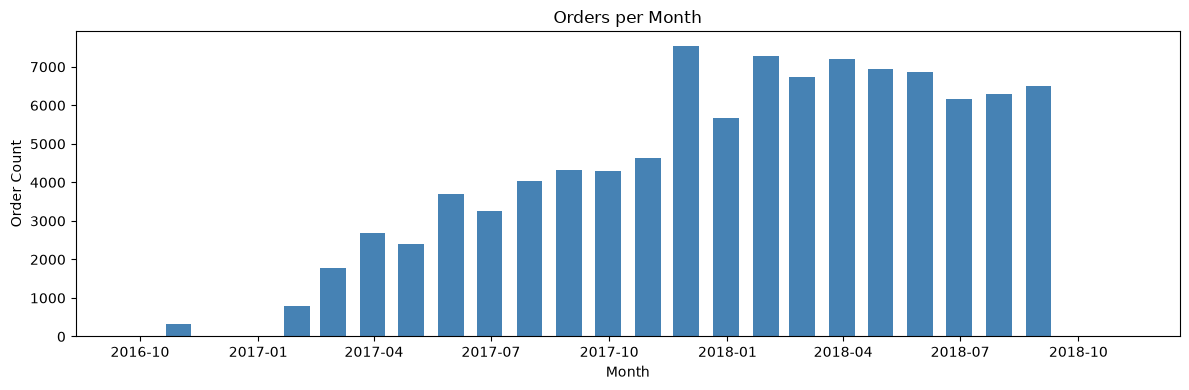

,month,order_count
16,2018-01-31,7269
17,2018-02-28,6728
18,2018-03-31,7211
19,2018-04-30,6939
20,2018-05-31,6873
21,2018-06-30,6167
22,2018-07-31,6292
23,2018-08-31,6512
24,2018-09-30,16
25,2018-10-31,4


In [5]:
monthly = (
    orders.set_index("order_purchase_timestamp")
    .resample("ME")["order_id"]
    .count()
    .reset_index()
)
monthly.columns = ["month", "order_count"]

plt.figure(figsize=(12, 4))
plt.bar(monthly["month"], monthly["order_count"], color="steelblue", width=20)
plt.title("Orders per Month")
plt.xlabel("Month")
plt.ylabel("Order Count")
plt.tight_layout()
plt.show()
monthly.tail(10)

## 4. Null Counts — All Raw Tables

In [6]:
tables_to_check = {
    "orders":         pd.read_sql("SELECT * FROM orders", engine),
    "order_items":    pd.read_sql("SELECT * FROM order_items", engine),
    "order_payments": pd.read_sql("SELECT * FROM order_payments", engine),
    "order_reviews":  pd.read_sql("SELECT * FROM order_reviews", engine),
    "products":       pd.read_sql("SELECT * FROM products", engine),
    "customers":      pd.read_sql("SELECT * FROM customers", engine),
}

for name, df in tables_to_check.items():
    null_cols = df.isnull().sum()
    null_cols = null_cols[null_cols > 0]
    if not null_cols.empty:
        print(f"\n── {name} ──")
        for col, cnt in null_cols.items():
            print(f"  {col:<45} {cnt:>7,}  ({cnt/len(df)*100:.1f}%)")
    else:
        print(f"\n── {name}  ✅ no nulls")


── orders ──
  order_approved_at                                 160  (0.2%)
  order_delivered_carrier_date                    1,783  (1.8%)
  order_delivered_customer_date                   2,965  (3.0%)

── order_items  ✅ no nulls

── order_payments  ✅ no nulls

── order_reviews ──
  review_comment_title                           87,656  (88.3%)
  review_comment_message                         58,247  (58.7%)

── products ──
  product_category_name                             610  (1.9%)
  product_name_lenght                               610  (1.9%)
  product_description_lenght                        610  (1.9%)
  product_photos_qty                                610  (1.9%)
  product_weight_g                                    2  (0.0%)
  product_length_cm                                   2  (0.0%)
  product_height_cm                                   2  (0.0%)
  product_width_cm                                    2  (0.0%)

── customers  ✅ no nulls


## 5. Order Status Distribution

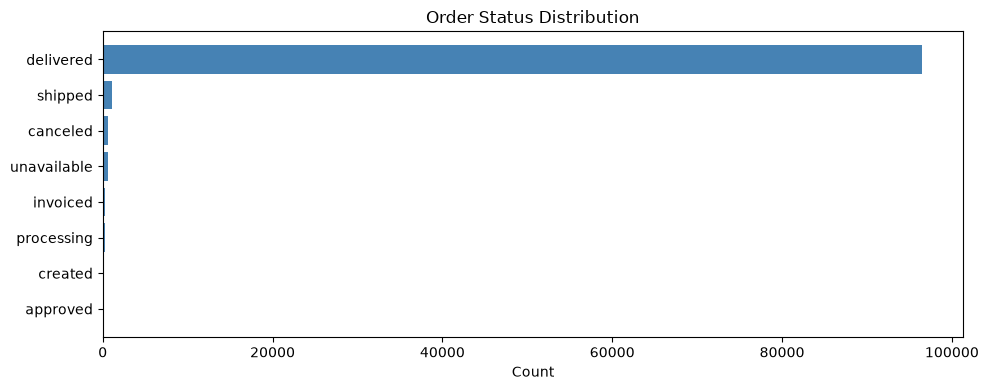

,status,count
0,delivered,96478
1,shipped,1107
2,canceled,625
3,unavailable,609
4,invoiced,314
5,processing,301
6,created,5
7,approved,2


In [7]:
status = orders["order_status"].value_counts().reset_index()
status.columns = ["status", "count"]

plt.figure(figsize=(10, 4))
plt.barh(status["status"], status["count"], color="steelblue")
plt.title("Order Status Distribution")
plt.xlabel("Count")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
status

## 6. Revenue Overview

In [8]:
order_items = pd.read_sql("SELECT * FROM order_items", engine)
print(f"Total items:          {len(order_items):,}")
print(f"Total revenue (BRL):  {order_items['price'].sum():,.2f}")
print(f"Avg price per item:   {order_items['price'].mean():.2f}")
print(f"Total freight (BRL):  {order_items['freight_value'].sum():,.2f}")
print(f"Negative prices:      {(order_items['price'] < 0).sum()}")

Total items:          112,650
Total revenue (BRL):  13,591,643.70
Avg price per item:   120.65
Total freight (BRL):  2,251,909.54
Negative prices:      0


In [9]:
order_items["price"].describe().round(2)

count    112650.00
mean        120.65
std         183.63
min           0.85
25%          39.90
50%          74.99
75%         134.90
max        6735.00
Name: price, dtype: float64

## 7. Payment Types

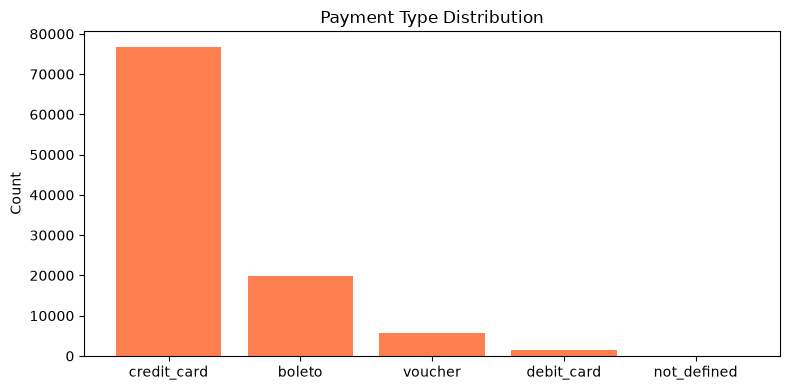

,payment_type,count
0,credit_card,76795
1,boleto,19784
2,voucher,5775
3,debit_card,1529
4,not_defined,3


In [10]:
payments = pd.read_sql("SELECT * FROM order_payments", engine)
pay_dist = payments["payment_type"].value_counts().reset_index()
pay_dist.columns = ["payment_type", "count"]

plt.figure(figsize=(8, 4))
plt.bar(pay_dist["payment_type"], pay_dist["count"], color="coral")
plt.title("Payment Type Distribution")
plt.ylabel("Count")
plt.tight_layout()
plt.show()
pay_dist

## 8. Review Score Distribution

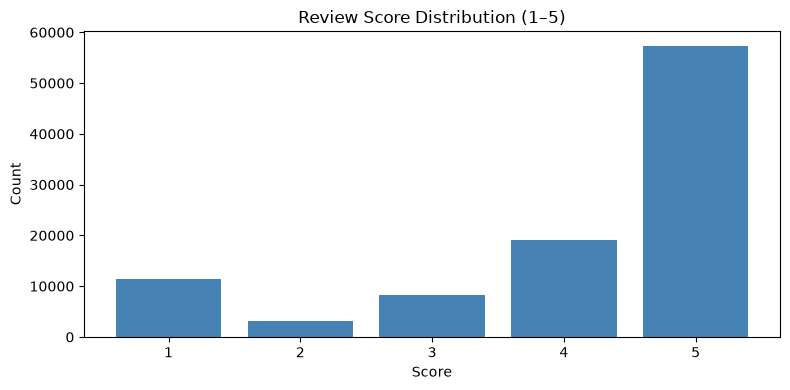

Avg review score: 4.09


In [11]:
reviews = pd.read_sql("SELECT * FROM order_reviews", engine)
score_dist = reviews["review_score"].value_counts().sort_index()

plt.figure(figsize=(8, 4))
plt.bar(score_dist.index, score_dist.values, color="steelblue")
plt.title("Review Score Distribution (1–5)")
plt.xlabel("Score")
plt.ylabel("Count")
plt.tight_layout()
plt.show()
print(f"Avg review score: {reviews['review_score'].mean():.2f}")

## 9. Top Product Categories

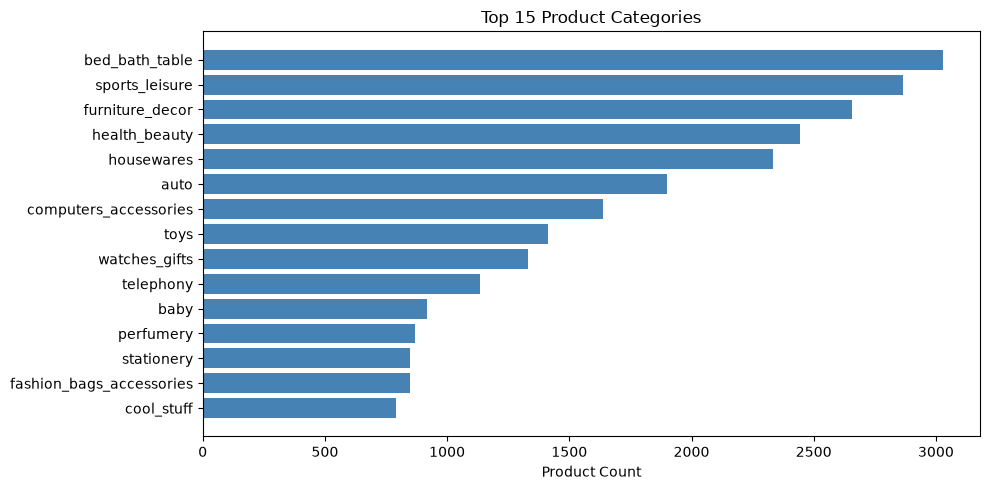

In [12]:
products = pd.read_sql("SELECT * FROM products", engine)
cat = pd.read_sql("SELECT * FROM category_translation", engine)
products = products.merge(cat, on="product_category_name", how="left")

top_cats = (
    products["product_category_name_english"]
    .fillna("unknown")
    .value_counts()
    .head(15)
    .reset_index()
)
top_cats.columns = ["category", "count"]

plt.figure(figsize=(10, 5))
plt.barh(top_cats["category"], top_cats["count"], color="steelblue")
plt.title("Top 15 Product Categories")
plt.xlabel("Product Count")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 10. Seller & Customer Geography

In [13]:
sellers  = pd.read_sql("SELECT * FROM sellers", engine)
customers = pd.read_sql("SELECT * FROM customers", engine)

print("── Top seller states ──")
print(sellers["seller_state"].value_counts().head(10).to_string())

print("\n── Top customer states ──")
print(customers["customer_state"].value_counts().head(10).to_string())

── Top seller states ──
seller_state
SP    1849
PR     349
MG     244
SC     190
RJ     171
RS     129
GO      40
DF      30
ES      23
BA      19

── Top customer states ──
customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020


## 11. Customer ID vs Unique ID

In [14]:
print(f"Total customer_id rows:        {len(customers):,}")
print(f"Distinct customer_unique_id:   {customers['customer_unique_id'].nunique():,}")
print(f"Repeat buyers (unique_id < id):{len(customers) - customers['customer_unique_id'].nunique():,}")

Total customer_id rows:        99,441
Distinct customer_unique_id:   96,096
Repeat buyers (unique_id < id):3,345


## 12. Geolocation Duplicates

In [15]:
geo = pd.read_sql("SELECT * FROM geolocation", engine)
print(f"Total rows:          {len(geo):,}")
print(f"Distinct ZIP codes:  {geo['geolocation_zip_code_prefix'].nunique():,}")
print(f"Duplicate ZIPs:      {len(geo) - geo['geolocation_zip_code_prefix'].nunique():,}")

Total rows:          1,000,163
Distinct ZIP codes:  19,015
Duplicate ZIPs:      981,148


In [16]:
engine.dispose()
print("Done.")

Done.
